# Marked Spatiotemporal Poisson Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/marked_spatiotemporal_from_scratch_and_numpyro.ipynb)

A **marked spatiotemporal point process** attaches an attribute $m_i$ — a *mark* — to each event $(s_i, t_i)$. Under the separable factorisation $\lambda(s, t, m) = \lambda(s, t) \, f(m \mid s, t)$, the joint log-likelihood splits into ground (location, time) and mark contributions:

$$
\log L = \sum_i [\log \lambda(s_i, t_i) + \log f(m_i \mid s_i, t_i)] - \Lambda.
$$

We use an **earthquake-style** example: a homogeneous space-time ground process plus magnitudes drawn from an Exponential mark distribution (the Gutenberg–Richter shape after a magnitude shift). The mark rate scales with time so larger events tend to occur later — a synthetic stand-in for a stress-release effect.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes import RectangularDomain, TemporalDomain
from xtremax.point_processes.distributions import (
    MarkedSpatioTemporalPP as MarkedStDist,
)
from xtremax.point_processes.operators import (
    HomogeneousSpatioTemporalPP as HppStOp,
)
from xtremax.point_processes.primitives import (
    sample_spatiotemporal_marks,
    spatiotemporal_marks_log_prob,
)


plt.rcParams["figure.figsize"] = (8.0, 4.0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From scratch — the primitives layer

In [2]:
spatial = RectangularDomain.from_size(jnp.array([10.0, 10.0]))
temporal = TemporalDomain.from_duration(5.0)
true_rate = 0.4

ground = HppStOp(rate=true_rate, spatial=spatial, temporal=temporal)
locs, times, mask, n = ground.sample(random.PRNGKey(0), max_events=512)
print(f"Ground draw: {int(n)} events.")

Ground draw: 179 events.


### Sample marks (location- and time-dependent)

Magnitude rate scales with time so events later in the window have larger marks on average.

In [3]:
beta_t_true = 0.4  # marks grow with time


def mark_distribution_fn(s, t, beta_t=beta_t_true, beta0=1.5):
    rate = jnp.exp(-(beta0 - beta_t * t))
    return dist.Exponential(rate=rate)


marks = sample_spatiotemporal_marks(
    random.PRNGKey(1),
    locs,
    times,
    mask,
    mark_distribution_fn,
)
print(
    f"Real-event mark range: {float(jnp.min(marks[mask])):.3f} – {float(jnp.max(marks[mask])):.3f}"
)

Real-event mark range: 0.000 – 16.037


Visualise: scatter on (x, y) with marker size proportional to mark, colour by time.

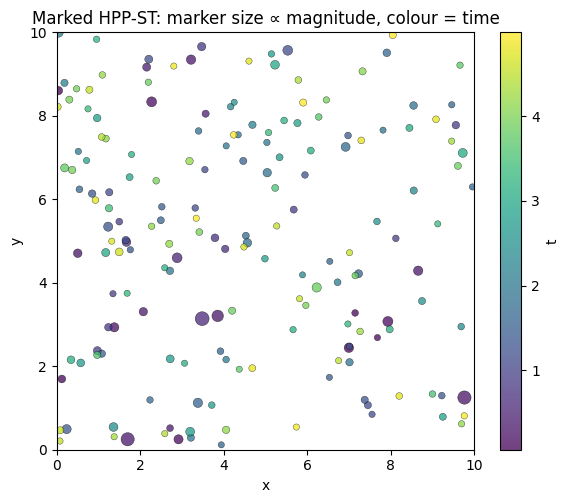

In [4]:
real_locs = locs[mask]
real_times = times[mask]
real_marks = marks[mask]
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    real_locs[:, 0],
    real_locs[:, 1],
    s=20.0 + 80.0 * real_marks / float(jnp.max(real_marks)),
    c=real_times,
    alpha=0.75,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.3,
)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Marked HPP-ST: marker size ∝ magnitude, colour = time")
plt.colorbar(sc, ax=ax, label="t")
plt.tight_layout()
plt.show()

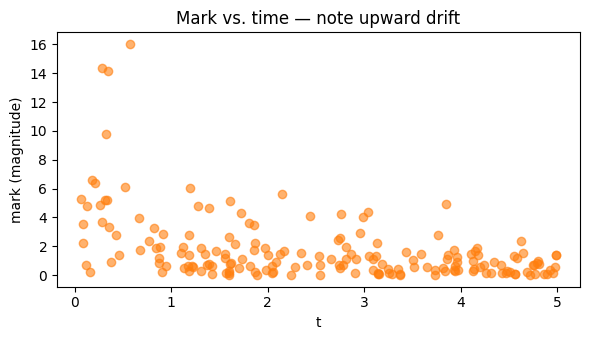

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(real_times, real_marks, alpha=0.6, color="C1")
ax.set_xlabel("t")
ax.set_ylabel("mark (magnitude)")
ax.set_title("Mark vs. time — note upward drift")
plt.tight_layout()
plt.show()

### Joint log-likelihood = ground + marks

In [6]:
ground_lp = ground.log_prob(locs, times, mask)
marks_lp = spatiotemporal_marks_log_prob(locs, times, marks, mask, mark_distribution_fn)
print(f"log L_ground  = {float(ground_lp):.3f}")
print(f"log L_marks   = {float(marks_lp):.3f}")
print(f"log L_joint   = {float(ground_lp + marks_lp):.3f}")

log L_ground  = -364.016
log L_marks   = -249.209
log L_joint   = -613.225


## 2. With NumPyro — recover the rate and the time-magnitude slope

In [7]:
def model(locs_obs, times_obs, mask_obs, marks_obs, spatial, temporal):
    rate = numpyro.sample("rate", dist.LogNormal(loc=0.0, scale=1.0))
    beta0 = numpyro.sample("beta0", dist.Normal(loc=0.0, scale=1.0))
    beta_t = numpyro.sample("beta_t", dist.Normal(loc=0.0, scale=0.5))

    def mark_fn(s, t):
        return dist.Exponential(rate=jnp.exp(-(beta0 - beta_t * t)))

    ground = HppStOp(rate=rate, spatial=spatial, temporal=temporal)
    spp = MarkedStDist(
        ground=ground, mark_distribution_fn=mark_fn, max_events=mask_obs.shape[0]
    )
    numpyro.factor("lik", spp.log_prob((locs_obs, times_obs, mask_obs, marks_obs)))


mcmc = MCMC(
    NUTS(model), num_warmup=400, num_samples=800, num_chains=1, progress_bar=False
)
mcmc.run(
    random.PRNGKey(2),
    locs_obs=locs,
    times_obs=times,
    mask_obs=mask,
    marks_obs=marks,
    spatial=spatial,
    temporal=temporal,
)
post = mcmc.get_samples()
for name, true_val in [("rate", true_rate), ("beta_t", beta_t_true)]:
    samples = post[name]
    print(
        f"{name}: posterior mean = {float(jnp.mean(samples)):.3f}, "
        f"95% CI = [{float(jnp.quantile(samples, 0.025)):.3f}, "
        f"{float(jnp.quantile(samples, 0.975)):.3f}], true = {true_val}"
    )

rate: posterior mean = 0.361, 95% CI = [0.315, 0.417], true = 0.4
beta_t: posterior mean = 0.382, 95% CI = [0.297, 0.474], true = 0.4


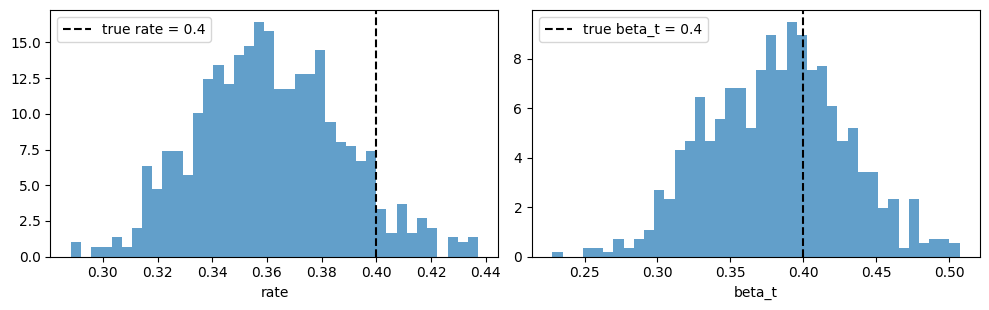

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, name, true_val in zip(axes, ["rate", "beta_t"], [true_rate, beta_t_true]):
    ax.hist(post[name], bins=40, density=True, alpha=0.7, color="C0")
    ax.axvline(true_val, color="k", linestyle="--", label=f"true {name} = {true_val}")
    ax.set_xlabel(name)
    ax.legend()
plt.tight_layout()
plt.show()